#### Sprint 10: Practical exercise of data cleaning and analysis.

- Dataset from a survey of workers.
- Need to ensure correct data processing (format and readability).
- **Goal of the sprint:** to apply cleaning, summarization, and analysis tasks using Pandas.
- Also includes process automation and solving complex problems.

In [59]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

### Level 1

#### 1. 
Import the file **sprint10.xlsx as a DataFrame**. Make sure the file is imported correctly, with the corresponding column names, **without manipulating the original file**.
**Sort** the DataFrame by country of origin. In case of a tie, sort by city name.
Display the **first 10 rows**.
Additionally, show throught a *print* that the **ID number (DNI) contains only unique values**.

In [60]:
# Import .xlsx file as df
file_to_process = r"sprint10.xlsx"

df = pd.read_excel(file_to_process, header=3)

# Rename first column (ID) and the rest of columns (translate them into English) for consistency
df = df.rename(columns={"Unnamed: 0":"df_ID",
                        "Nom": "name", 
                        "Cognoms":"surname",
                        "DNI":"ID", 
                        "País d'origen":"country", 
                        "Ciutat":"city", 
                        "Dia de Naixement":"birth_day", 
                        "Mes de Naixement":"birth_month", 
                        "Any de Naixement":"birth_year", 
                        "Gènere":"gender",
                        "Salari mensual":"monthly_salary",
                        "Fills":"children",
                        "No Fills":"no_children",
                        "Grup Professional":"professional_group"
                        })

# Sort by country of origin and city name
df.sort_values(["country", "city"], inplace=True)

# Display first 10 rows
df.head(10)

,df_ID,name,surname,ID,country,city,birth_day,birth_month,birth_year,gender,monthly_salary,children,no_children,professional_group
21,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [61]:
# ID unique values, through a print
# ID = df_ID (1000), thus, they are unique

print(df.nunique())

df_ID                 1000
name                    80
surname                183
ID                    1000
country                 10
city                    26
birth_day               28
birth_month             12
birth_year              56
gender                   4
monthly_salary         767
children                 1
no_children              1
professional_group       4
dtype: int64


#### 2.
- Create a **column for the full name**.
- Create a **column indicating whether the person was born in Spain or not**.
- Set the **ID number (DNI) as the DataFrame's index** (row labels).
- **Replace the column names** "Dia de Naixement", "Mes de Naixement", and "Any de Naixement" with "Dia", "Mes", and "Any".
- **Replace** H with Home (Man), D with Dona (Woman), A with Altres (Other), and NC with a missing value (nan/null/na).
Display all the **changes** you have made **in a single table**.

In [62]:
# New column for full_name
df.insert(1, 'full_name', df['surname'] + ' ' + df['name'])

# New column for Spain (or not) with NumPy
df.insert(6, 'spain', np.where(df['country'] == 'Espanya', True, False))

# ID as df's index
df = df.set_index('ID')

# Rename columns as required
df = df.rename(columns={'birth_day':'day', 'birth_month': 'month', 'birth_year':'year'})

# Replace gender values
df['gender'] = df['gender'].replace(['D','H','A', 'NC'],['woman', 'man', 'others', 'NaN'])

df

,df_ID,full_name,name,surname,country,spain,city,day,month,year,gender,monthly_salary,children,no_children,professional_group
ID,,,,,,,,,,,,,,,
28973553Z,21,Schneider Fischer Mia,Mia,Schneider Fischer,Alemanya,False,Berlín,22,10,1976,others,951 €,NaN,1.0,Grup A
37399141L,154,Schneider Fischer Laura,Laura,Schneider Fischer,Alemanya,False,Berlín,2,2,1958,woman,1.769 €,1.0,NaN,Grup B
37368317L,224,Schneider Schneider Lea,Lea,Schneider Schneider,Alemanya,False,Berlín,23,10,2005,woman,2.013 €,NaN,1.0,Grup B
21390098Z,278,Fischer Mia,Mia,Fischer,Alemanya,False,Berlín,11,8,1950,woman,1.557 €,1.0,NaN,Grup B
44060014R,602,Schneider Jonas,Jonas,Schneider,Alemanya,False,Berlín,22,11,1985,man,2.754 €,1.0,NaN,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,547,Taylor Jones Emily,Emily,Taylor Jones,Regne Unit,False,Manchester,28,3,1958,woman,2.033 €,NaN,1.0,Grup B
57441590Y,728,Brown Jones George,George,Brown Jones,Regne Unit,False,Manchester,27,12,1979,man,1.130 €,1.0,NaN,Grup A
58204038A,751,Brown Brown Olivia,Olivia,Brown Brown,Regne Unit,False,Manchester,28,8,1952,others,1.023 €,NaN,1.0,Grup A


#### 3.
Merge the columns "Fills" (Children) and "No Fills" (No Children) into a **single column, using the .apply() method** and defining a **function** to solve the problem. The new column should be named "Fills" (Children) and take the **values "Sí" (Yes) or "No"**.

In [63]:
# This function overwrites the column 'children'

def children_column(row):
    if pd.isna(row['children']) and row['no_children'] == 1.0:
        return 'No'
    elif row['children'] == 1.0 and pd.isna(row['no_children']):
        return 'Yes'
    else:
        return 'NaN'

df['children'] = df.apply(children_column, axis=1)

# Drop 'no_children' column
df = df.drop(['no_children'], axis=1)

df

,df_ID,full_name,name,surname,country,spain,city,day,month,year,gender,monthly_salary,children,professional_group
ID,,,,,,,,,,,,,,
28973553Z,21,Schneider Fischer Mia,Mia,Schneider Fischer,Alemanya,False,Berlín,22,10,1976,others,951 €,No,Grup A
37399141L,154,Schneider Fischer Laura,Laura,Schneider Fischer,Alemanya,False,Berlín,2,2,1958,woman,1.769 €,Yes,Grup B
37368317L,224,Schneider Schneider Lea,Lea,Schneider Schneider,Alemanya,False,Berlín,23,10,2005,woman,2.013 €,No,Grup B
21390098Z,278,Fischer Mia,Mia,Fischer,Alemanya,False,Berlín,11,8,1950,woman,1.557 €,Yes,Grup B
44060014R,602,Schneider Jonas,Jonas,Schneider,Alemanya,False,Berlín,22,11,1985,man,2.754 €,Yes,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,547,Taylor Jones Emily,Emily,Taylor Jones,Regne Unit,False,Manchester,28,3,1958,woman,2.033 €,No,Grup B
57441590Y,728,Brown Jones George,George,Brown Jones,Regne Unit,False,Manchester,27,12,1979,man,1.130 €,Yes,Grup A
58204038A,751,Brown Brown Olivia,Olivia,Brown Brown,Regne Unit,False,Manchester,28,8,1952,others,1.023 €,No,Grup A


#### 4.
- Create a **summary table** that shows the **mean, median, minimum, and maximum salary by Gender**.
- **Sort** the table by the mean salary.

In [64]:
# As I need column 'monthly_salary', I first check its data type.
df.info()
# Now, it's a str, so I need to cast it.

<class 'pandas.DataFrame'>
Index: 1000 entries, 28973553Z to 82046699J
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   df_ID               1000 non-null   int64
 1   full_name           1000 non-null   str  
 2   name                1000 non-null   str  
 3   surname             1000 non-null   str  
 4   country             1000 non-null   str  
 5   spain               1000 non-null   bool 
 6   city                1000 non-null   str  
 7   day                 1000 non-null   int64
 8   month               1000 non-null   int64
 9   year                1000 non-null   int64
 10  gender              1000 non-null   str  
 11  monthly_salary      1000 non-null   str  
 12  children            1000 non-null   str  
 13  professional_group  1000 non-null   str  
dtypes: bool(1), int64(4), str(9)
memory usage: 110.4+ KB


In [65]:
# Data cleaning (remove €, thousand separators, spaces) + cast to int
df['monthly_salary'] = df['monthly_salary'].str.replace('€', '').str.replace('.', '').str.strip().astype(int)

# Summary table 1 (group by gender, get salary stats (mean, min, max, median), sort by mean)
summary_df_1 = df.groupby(['gender'])[['monthly_salary']].describe()
summary_df_1 = summary_df_1[[
    ('monthly_salary', 'mean'), 
    ('monthly_salary', 'min'), 
    ('monthly_salary', 'max'), 
    ('monthly_salary', '50%')
]]
summary_df_1.sort_values(('monthly_salary', 'mean')).round(2)

summary_df_1

monthly_salary                       
                 mean    min     max     50%
gender                                      
NaN       1568.866667  758.0  2969.0  1443.0
man       1643.249443  737.0  3356.0  1531.0
others    1626.588235  703.0  3175.0  1545.0
woman     1469.443182  665.0  3021.0  1361.5

#### 5.
- Create a **summary table** with the **mean salary by gender (rows) and country of origin (columns)**.
- Add the **medians** to the margin of the table.
- (EXTRA): Apply **conditional formatting** to the table to **highlight the highest values** in a more intense color.

In [66]:
# Summary table 2
summary_df_2 = pd.crosstab(df['gender'], df['country'], df['monthly_salary'], aggfunc= 'mean', margins= True, margins_name= 'median').round(2)

# Monthly_salary median by gender (row)
gender_median = df.groupby('gender')['monthly_salary'].median()
summary_df_2['median'] = gender_median

# Monthly_salary median by country (column)
country_median = df.groupby('country')['monthly_salary'].median()
summary_df_2.loc['median'] = country_median

# Global median (corner cell)
summary_df_2.loc['median', 'median'] = df['monthly_salary'].median()

# Conditional formatting
style_1 = summary_df_2.style.background_gradient('coolwarm')

style_1

country,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,median
gender,,,,,,,,,,,
NaN,1931.500000,1135.670000,1252.000000,1597.140000,1573.000000,1316.000000,1365.500000,1583.000000,1553.500000,1758.000000,1443.000000
man,2067.430000,1583.290000,1554.670000,1682.110000,1389.250000,1672.880000,1531.000000,1625.000000,1497.000000,1162.560000,1531.000000
others,951.000000,1141.000000,1030.000000,1706.180000,nan,1423.000000,1365.000000,1372.000000,1765.000000,1921.000000,1545.000000
woman,1804.310000,1291.800000,1497.750000,1460.160000,1566.470000,1247.180000,1405.210000,1517.800000,1488.550000,1489.460000,1361.500000
median,1769.000000,1292.000000,1355.000000,1442.000000,1473.500000,1358.000000,1414.000000,1531.000000,1431.000000,1274.000000,1438.000000


#### 6.
Create a **new column** that contains the **birth date in Datetime format** using the day, month, and year columns. Using this column, create a **function** that, given a date, **calculates the current age as of today's date**.
- Use the function you just created to **generate a new column in the DataFrame with the current age**.

In [67]:
# New column with birth_date in datetime format
df.insert(4, 'birth_date', pd.to_datetime(df[['year', 'month', 'day']]))

# This function calculates current age as of today's date
def current_age(born):
    now = datetime.date.today()           
    return now.year - born.year - ((now.month, now.day) < (born.month, born.day))

# New column with crrent age (using the function)
df.insert(5, 'current_age', df['birth_date'].apply(lambda x: current_age(x)))

df

,df_ID,full_name,name,surname,birth_date,current_age,country,spain,city,day,month,year,gender,monthly_salary,children,professional_group
ID,,,,,,,,,,,,,,,,
28973553Z,21,Schneider Fischer Mia,Mia,Schneider Fischer,1976-10-22,49,Alemanya,False,Berlín,22,10,1976,others,951,No,Grup A
37399141L,154,Schneider Fischer Laura,Laura,Schneider Fischer,1958-02-02,68,Alemanya,False,Berlín,2,2,1958,woman,1769,Yes,Grup B
37368317L,224,Schneider Schneider Lea,Lea,Schneider Schneider,2005-10-23,20,Alemanya,False,Berlín,23,10,2005,woman,2013,No,Grup B
21390098Z,278,Fischer Mia,Mia,Fischer,1950-08-11,75,Alemanya,False,Berlín,11,8,1950,woman,1557,Yes,Grup B
44060014R,602,Schneider Jonas,Jonas,Schneider,1985-11-22,40,Alemanya,False,Berlín,22,11,1985,man,2754,Yes,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,547,Taylor Jones Emily,Emily,Taylor Jones,1958-03-28,68,Regne Unit,False,Manchester,28,3,1958,woman,2033,No,Grup B
57441590Y,728,Brown Jones George,George,Brown Jones,1979-12-27,46,Regne Unit,False,Manchester,27,12,1979,man,1130,Yes,Grup A
58204038A,751,Brown Brown Olivia,Olivia,Brown Brown,1952-08-28,73,Regne Unit,False,Manchester,28,8,1952,others,1023,No,Grup A


### Level 2

#### 1.
Using the following DataFrame, attach the **"Increment" column** to the previous level's DataFrame.
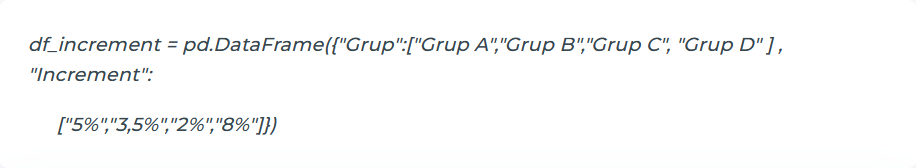
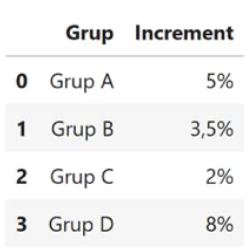
- **Update the salary column** based on the percentages provided. Do not manually modify the increments; write Python code to perform the necessary conversions.



In [68]:
# Create df_increment
df_increment = pd.DataFrame({'Grup': ['Grup A', 'Grup B', 'Grup C', 'Grup D'],
                                'Increment': ['5%', '3,5%', '2%', '8%']})

df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [69]:
# New column with increment based on professional group (with map)
df['Increment'] = df['professional_group'].map(df_increment.set_index('Grup')['Increment'])

# New column with updated monthly salary, based on increment
df['updated_monthly_salary'] = df['monthly_salary'] * (1 + df['Increment'].str.replace('%', '').str.replace(',', '.').astype(float) / 100).round(2)

df

,df_ID,full_name,name,surname,birth_date,current_age,country,spain,city,day,month,year,gender,monthly_salary,children,professional_group,Increment,updated_monthly_salary
ID,,,,,,,,,,,,,,,,,,
28973553Z,21,Schneider Fischer Mia,Mia,Schneider Fischer,1976-10-22,49,Alemanya,False,Berlín,22,10,1976,others,951,No,Grup A,5%,998.55
37399141L,154,Schneider Fischer Laura,Laura,Schneider Fischer,1958-02-02,68,Alemanya,False,Berlín,2,2,1958,woman,1769,Yes,Grup B,"3,5%",1822.07
37368317L,224,Schneider Schneider Lea,Lea,Schneider Schneider,2005-10-23,20,Alemanya,False,Berlín,23,10,2005,woman,2013,No,Grup B,"3,5%",2073.39
21390098Z,278,Fischer Mia,Mia,Fischer,1950-08-11,75,Alemanya,False,Berlín,11,8,1950,woman,1557,Yes,Grup B,"3,5%",1603.71
44060014R,602,Schneider Jonas,Jonas,Schneider,1985-11-22,40,Alemanya,False,Berlín,22,11,1985,man,2754,Yes,Grup D,8%,2974.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,547,Taylor Jones Emily,Emily,Taylor Jones,1958-03-28,68,Regne Unit,False,Manchester,28,3,1958,woman,2033,No,Grup B,"3,5%",2093.99
57441590Y,728,Brown Jones George,George,Brown Jones,1979-12-27,46,Regne Unit,False,Manchester,27,12,1979,man,1130,Yes,Grup A,5%,1186.50
58204038A,751,Brown Brown Olivia,Olivia,Brown Brown,1952-08-28,73,Regne Unit,False,Manchester,28,8,1952,others,1023,No,Grup A,5%,1074.15


#### 2.
- Using a **loop**, **export the data** for each Professional Group into 4 files (.xlsx or .csv format).
For example: "dades_GrupA.xlsx", "dades_GrupB.xlsx" ...
- Export a 5th DataFrame in .xlsx or .csv format that contains **how many workers there are per Professional Group**, what their **mean salary** is, and what their **median age** is.


In [70]:
# Loop to export files
for group in df['professional_group'].unique():                 
    group_df = df[df['professional_group'] == group]            
    group_df.to_csv(f'{group}.csv')

# New df with: how many workers there are per PG, their mean salary and their median age (with agg)
summary_df_3 = df.groupby('professional_group').agg(            
    worker_count=('full_name', 'count'),                        
    mean_salary=('monthly_salary', 'mean'),                     
    median_age=('current_age', 'median')                        
                                                    ) .round(2)                                             
# Export new df
summary_df_3.to_csv('professional_group_summary.csv')

### Level 3

1. Create a function that takes a dataframe as an input parameter. The function must automatically create (and export) a graph for each column of the dataframe. For example:

- a histogram/boxplot if the variable is numeric
- a bar chart of the most frequent values if it is categorical
- a bar chart of the most frequent years if the data is in date format.

The idea is to create a function that works for any dataframe, not just the one we have worked with so far.

Show the result of the function on one of the example datasets contained in the **seaborn package**. For example, iris, penguins, or titanic.

**Keep in mind that in the next sprint you will work exclusively with graphs. The objective of this exercise is not to create highly elaborate graphs, but to solve a need quickly and automatically.**

In [71]:
# Load dataset from seaborn (penguins)
penguins = sns.load_dataset('penguins')
penguins
#penguins.dtypes      # (to get to know the df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
# This function creates and exports a graph for each column, depending on its data type (bool, numeric (int or float), categorical, datetime)

def graph_export(df):
    for column in df.columns:
        if pd.api.types.is_bool_dtype(df[column]):      
            plt.figure()
            df[column].value_counts().plot(kind='bar')
            plt.title(f'More frequent values in {column}')
            plt.savefig(f'{column}_bar.png')

        elif pd.api.types.is_numeric_dtype(df[column]):
            plt.figure()                                              
            sns.histplot(df[column], kde=True)
            plt.title(f'Histogram of {column}')
            plt.savefig(f'{column}_histogram.png')
            
        elif pd.api.types.is_categorical_dtype(df[column]):
            plt.figure()
            sns.countplot(x=df[column])                                 
            plt.title(f'Bar chart of {column}')
            plt.savefig(f'{column}_bar_chart.png')
            
        elif pd.api.types.is_datetime64_any_dtype(df[column]):
            df[column] = pd.to_datetime(df[column], errors='coerce')             # Invalid dates become NaT
            df['year'] = df[column].dt.year
            plt.figure()
            df['year'].value_counts().plot(kind='bar')                                                
            plt.title(f'More frequent years in {column}')
            plt.savefig(f'{column}_years_bar_chart.png')
            
        plt.close()

graph_export(penguins)

C:\Users\Asus\AppData\Local\Temp\ipykernel_26236\3144861344.py:17: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[column]):
C:\Users\Asus\AppData\Local\Temp\ipykernel_26236\3144861344.py:17: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[column]):


2. Load the file "matriu_distancies.xlsx" into pandas, so that the row names and column names are those of the cities. Remove "Las Palmas de Gran Canaria" and "Palma" so that we can make the journey by car.

Source: Mejores Rutas

We are interested in visiting all the main cities of Spain, covering the minimum possible distance.
You don't need to do it optimally; we expect you to develop a reasonable solution using the tools you currently have.
For example, a simple (though not optimal) approach would be to always go to the nearest city that we haven't visited yet.
Create a function that, given the distance matrix and the starting city, makes a route proposal that is as short as possible (with the tools you have), returning a list with the visit order. Also provide the total distance traveled.

(EXTRA) From which city would the route be shortest using the proposed algorithm?

In [73]:
# Load file with cities as row and column names
new_df = pd.read_excel("matriu_distancies.xlsx", index_col=0)
new_df

# Remove "Las Palmas de Gran Canaria" and "Palma"
new_df = new_df.drop(["Las Palmas de Gran Canaria", "Palma"], axis=0)
new_df = new_df.drop(["Las Palmas de Gran Canaria", "Palma"], axis=1)

new_df

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


In [74]:
# This function receives distance matrix and starting city, and proposes the shortest route possible.
# It returns list with visit order, plus total distance traveled.

def shortest_route(distances, start_city):
    cities = distances.index.tolist()               # List of cities
    cities.remove(start_city)
    route = [start_city]
    total_distance = 0
    
    while cities:
        last_city = route[-1]
        next_city = min(cities, key=lambda city: distances.loc[last_city, city])    # Compare distances and get the closest one
        total_distance += distances.loc[last_city, next_city]
        route.append(next_city)
        cities.remove(next_city)
    
    return route, total_distance

start_city = "Barcelona"
route, total_distance = shortest_route(new_df, start_city)
print("Proposed route:", route)
print("Total distance traveled:", total_distance)

Proposed route: ['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo']
Total distance traveled: 2778.0


In [75]:
# Where to start in order for the route to be shortest?

shortest_distance = None
best_start_city = None

for city in new_df.index:
    route, total_distance = shortest_route(new_df, city)
    if shortest_distance is None or total_distance < shortest_distance:
        shortest_distance = total_distance
        best_start_city = city

print("Best starting city:", best_start_city)
print("Shortest total distance:", shortest_distance)

Best starting city: Barcelona
Shortest total distance: 2778.0
